In [2]:
#installing the libraries numpy for numerical operations,
# pandas for data manipulation,
# matplotlib and seaborn for data visualization, 
# and scikit-learn for machine learning algorithms.
import pandas as pd 
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.DataFrame(pd.read_csv(r'C:\Users\MSI\Desktop\Heart Disease\Data\data.csv'))
df.info()

#The dataset contains 14 columns, with a mix of numerical and categorical data types.
#The target variable is 'target', which indicates the presence of heart disease (1) or its absence (0). 
#The Columns are as follows:
#1. age: Age of the patient (numerical)
#2. sex: Gender of the patient (categorical)
#3. cp: Chest pain type (categorical)
#4. trestbps: Resting blood pressure (numerical)
#5. chol: Serum cholesterol level (numerical)
#6. fbs: Fasting blood sugar > 120 mg/dl (categorical)
#7. restecg: Resting electrocardiographic results (categorical)
#8. thalach: Maximum heart rate achieved (numerical)
#9. exang: Exercise-induced angina (categorical)
#10. oldpeak: ST depression induced by exercise relative to rest (numerical)
#11. slope: Slope of the peak exercise ST segment (categorical)
#12. ca: Number of major vessels (0-3) colored by fluoroscopy ( numerical)
#13. thal: Thalassemia (categorical)
#14. target: Presence of heart disease (1) or absence (0) (categorical)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [13]:
df.isna().sum()
#The Train dataset doesn't have any null values, which is a good sign for data quality. 

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [14]:
df.duplicated().sum()
#There are no duplicate rows in the Train dataset, which is beneficial for model training and analysis

np.int64(0)

In [15]:
df["Heart Disease"].value_counts()
#Dataset is slightly imbalanced, we need to fix this imbalance before training the model.

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

C:\Users\MSI\AppData\Local\Temp\ipykernel_1160\3247461577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Heart Disease", data=df, palette="Set2")


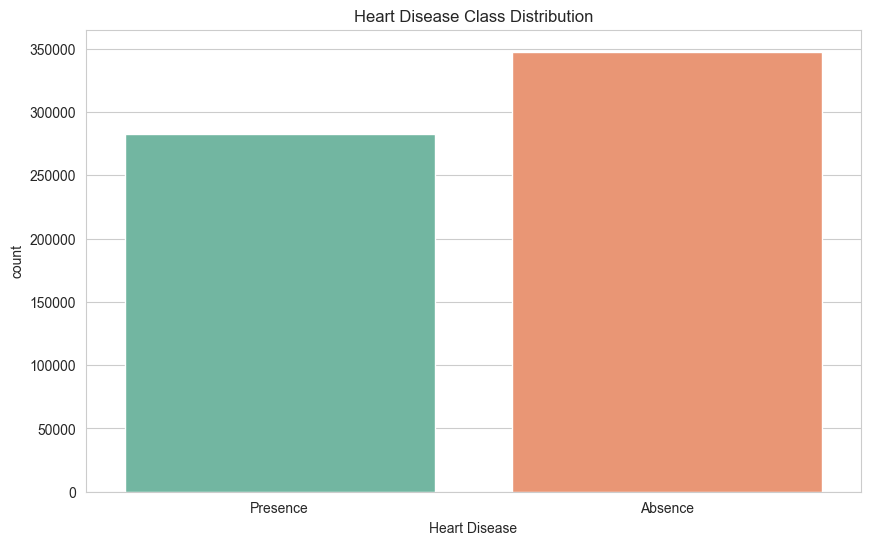

In [16]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# 1️⃣ Visualize the target variable
sns.countplot(x="Heart Disease", data=df, palette="Set2")
plt.title("Heart Disease Class Distribution")
plt.show()
#Dataset is slightly imbalanced as the plot shows.

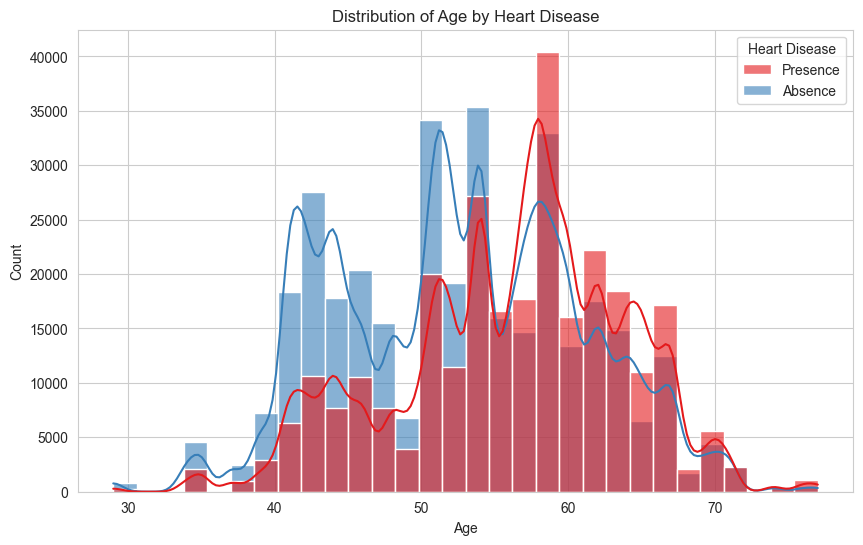

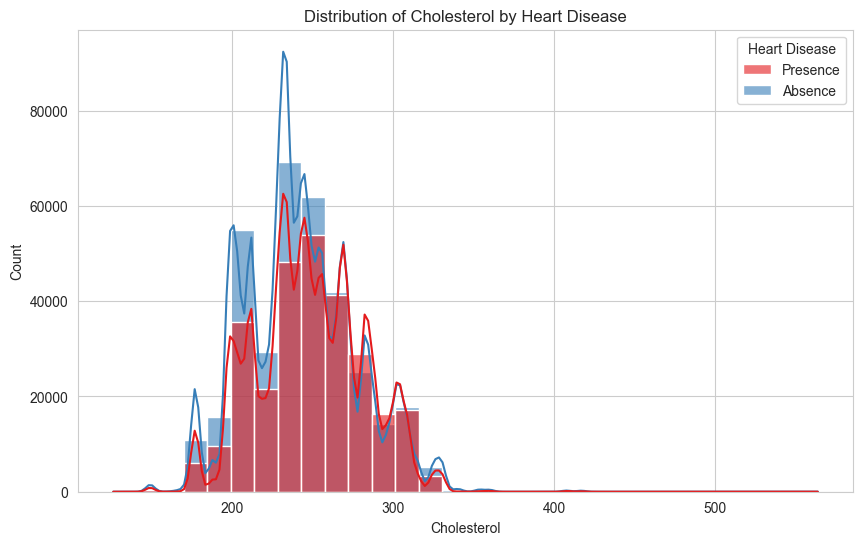

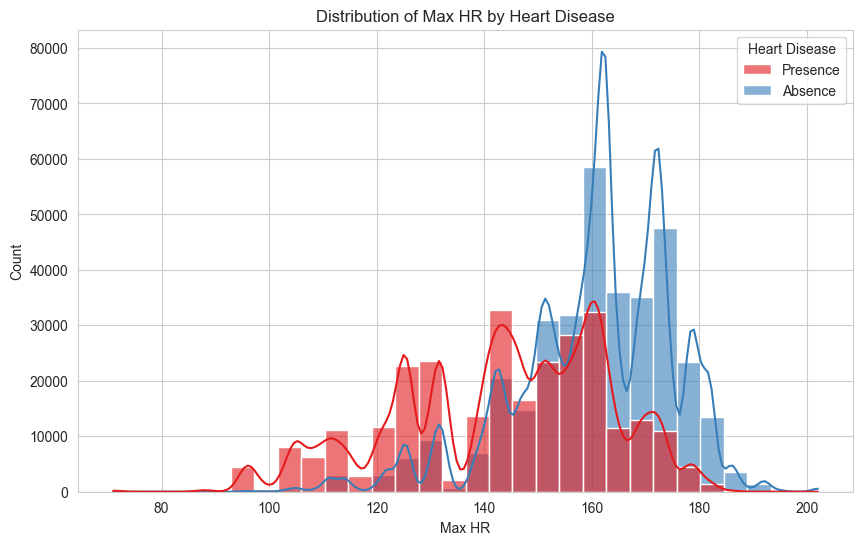

In [17]:
numerical_features = ["Age","Cholesterol", "Max HR"]
for feature in numerical_features:
    plt.figure()
    sns.histplot(df, x=feature, hue="Heart Disease", kde=True, palette="Set1", alpha=0.6, bins=30)
    plt.title(f"Distribution of {feature} by Heart Disease")
    plt.show()
    
#The distribution of age, cholesterol, and max heart rate shows some differences between those with and without heart disease.
#The distribution of age by Heart Disease shows that individuals with heart disease tend to be older, with a higher concentration around the age of 60-70.
#The distribution of cholesterol levels indicates that individuals with heart disease often have higher cholesterol levels compared to individuals without heart disease.
#The distribution of maximum heart rate achieved shows that individuals with heart disease tend to have lower maximum heart rates compared to those without heart disease.

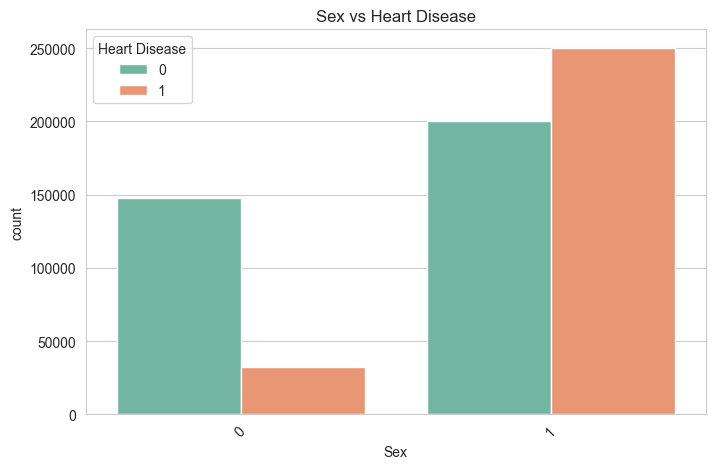

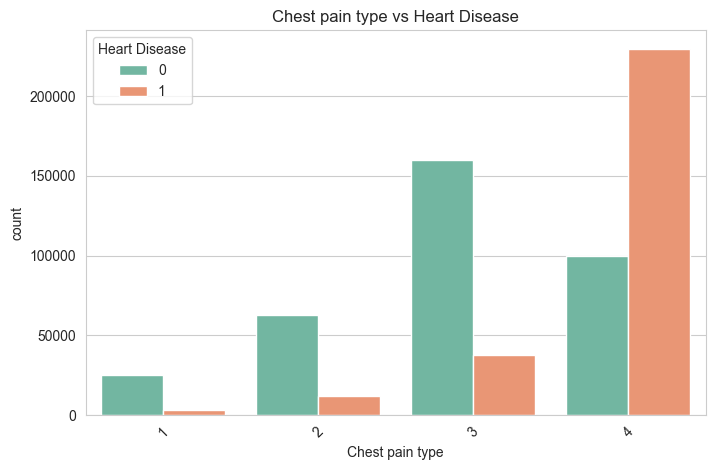

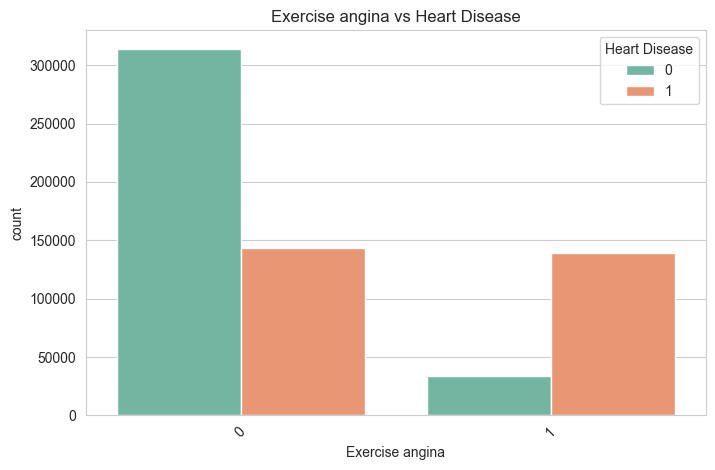

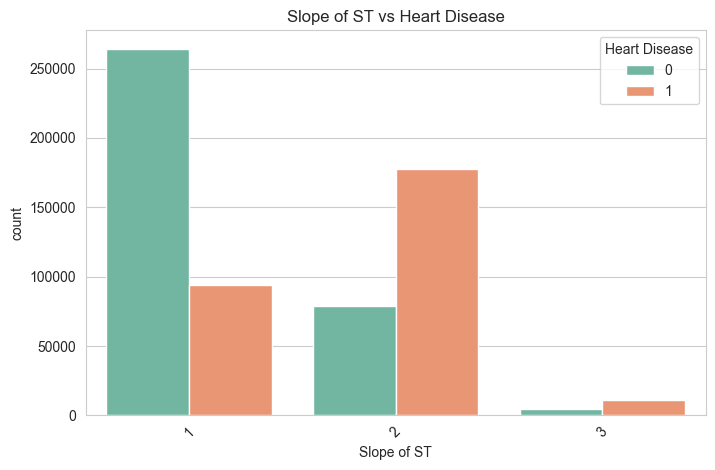

In [21]:


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

categorical_features = [
    "Sex",
    "Chest pain type",
    "Exercise angina",
    "Slope of ST"
]

for feature in categorical_features:
    plt.figure()
    sns.countplot(data=df, x=feature, hue="Heart Disease", palette="Set2")
    plt.title(f"{feature} vs Heart Disease")
    plt.xticks(rotation=45)
    plt.show()


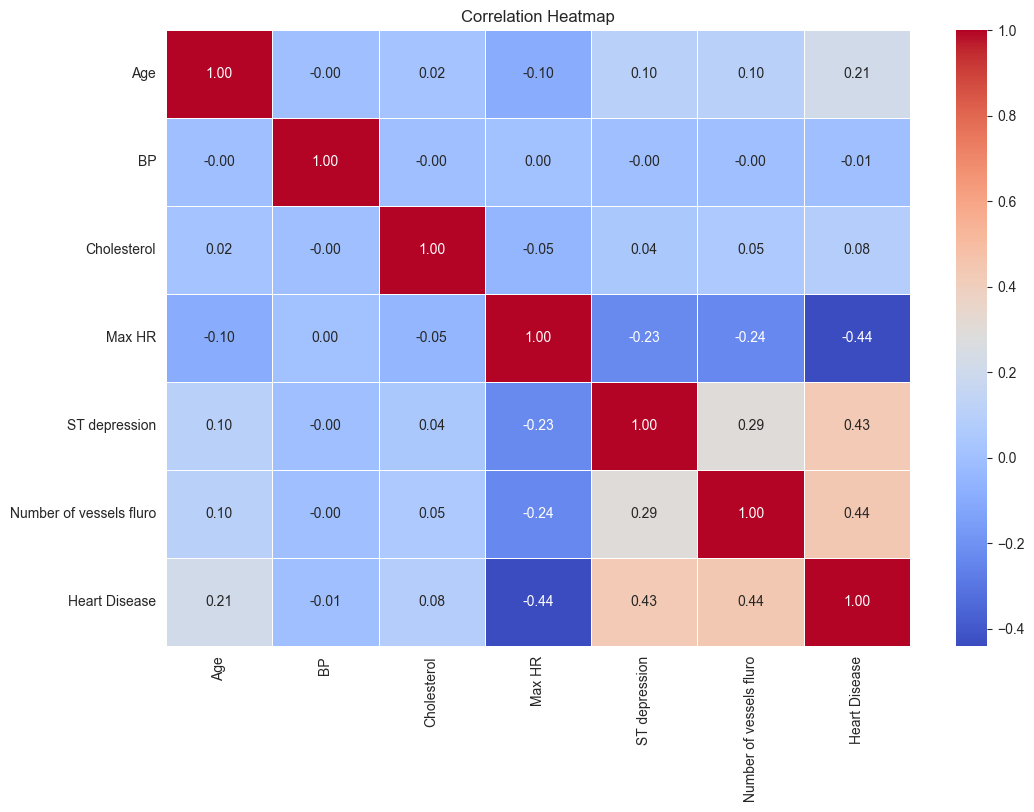

Heart Disease              1.000000
Number of vessels fluro    0.438604
ST depression              0.430641
Age                        0.212091
Cholesterol                0.082753
BP                        -0.005181
Max HR                    -0.440985
Name: Heart Disease, dtype: float64


In [20]:
#we encode Heart Disease to 0/1
df["Heart Disease"] = df["Heart Disease"].map({"Absence": 0, "Presence": 1})

plt.figure(figsize=(12,8))

# Only numerical columns
numerical_features = [
    "Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"
]

corr_matrix = df[numerical_features + ["Heart Disease"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr_target = corr_matrix["Heart Disease"].sort_values(ascending=False)
print(corr_target)


In [19]:
print(df.columns)


Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')
